In [1]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Age'] >= Q1 - 1.5*IQR) & (df['Age'] <= Q3 + 1.5*IQR)]

print(df.shape)

(703, 12)


In [9]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,703.000000,703.000000,703.000000,703.000000,703.000000,703.000000,703.000000
mean,449.290185,0.411095,2.244666,29.072077,0.519203,0.435277,34.785093
std,258.604497,0.492383,0.835397,13.728478,0.934836,0.858015,53.255433
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,444.000000,0.000000,3.000000,28.000000,0.000000,0.000000,15.741700
75%,678.500000,1.000000,3.000000,38.000000,1.000000,1.000000,33.000000
max,891.000000,1.000000,3.000000,64.000000,5.000000,6.000000,512.329200


In [11]:
df['Survived'].value_counts()

,count
Survived,
0,414
1,289


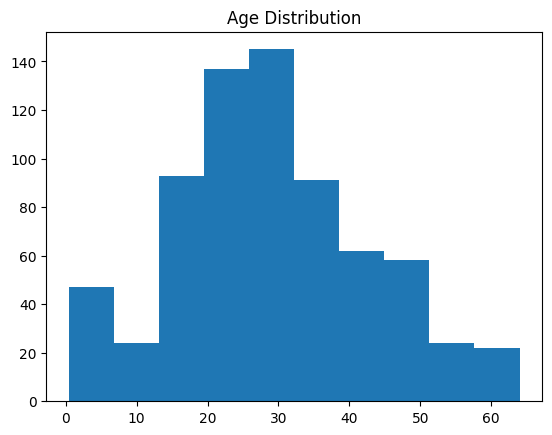

In [12]:
import matplotlib.pyplot as plt

plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()

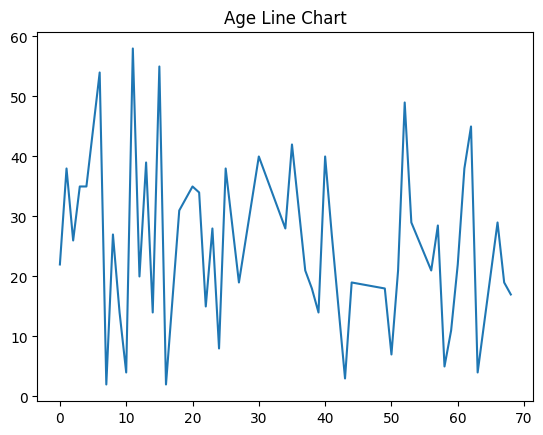

In [13]:
plt.plot(df['Age'].head(50))
plt.title("Age Line Chart")
plt.show()

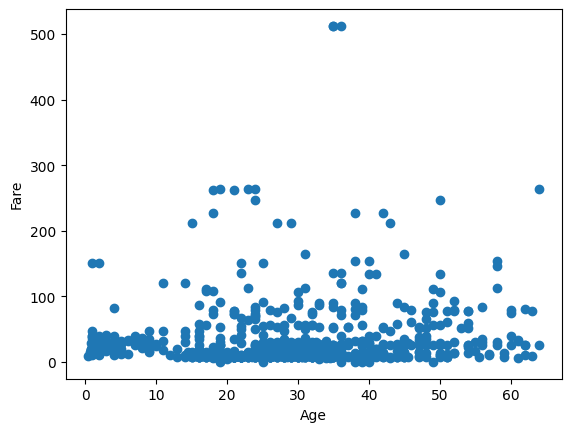

In [14]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

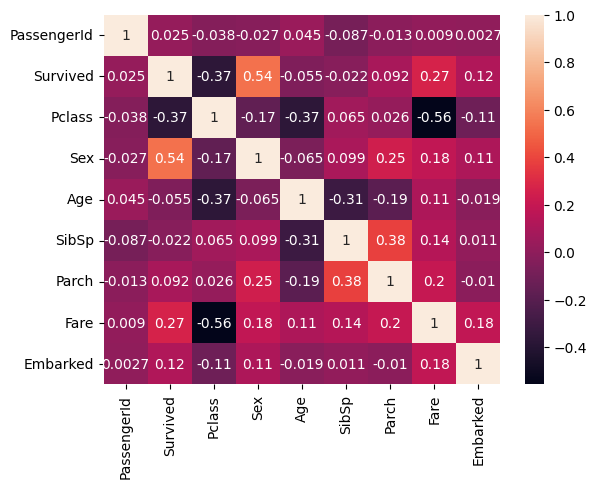

In [15]:
import seaborn as sns

temp = df.copy()
temp['Sex'] = temp['Sex'].map({'male':0,'female':1})
temp['Embarked'] = temp['Embarked'].map({'S':0,'C':1,'Q':2})

sns.heatmap(temp.corr(numeric_only=True), annot=True)
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [19]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

In [20]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Survived', axis=1)
y = df['Survived']

X = StandardScaler().fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

Logistic Regression Accuracy: 0.7801418439716312


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))

Decision Tree Accuracy: 0.7943262411347518


In [25]:
print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))

Logistic Regression: 0.7801418439716312
Decision Tree: 0.7943262411347518


# **summary**
The Titanic dataset was cleaned by handling missing values, removing outliers using the IQR method, and removing duplicate records. Exploratory Data Analysis (EDA) was performed using summary statistics and visualizations such as histogram, line chart, scatter plot, and correlation heatmap. Categorical variables were encoded using Label Encoding, and numerical features were standardized using StandardScaler. Logistic Regression and Decision Tree models were trained to predict passenger survival, and their accuracies were compared to identify the better-performing model.